In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/gdrive')
import os

# Try to read the CSV file. If the previous `ls` command shows the file, uncomment and use the correct path.
folder_path = '/content/gdrive/MyDrive/Time series Projet/backend/data/separted'
path_x_train = f'{folder_path}/X_train.csv'
path_y_train = f'{folder_path}/y_train.csv'
path_x_test = f'{folder_path}/X_test.csv'
path_y_test = f'{folder_path}/y_test.csv'
df_x_train = pd.read_csv(path_x_train)
df_y_train = pd.read_csv(path_y_train)
df_x_test = pd.read_csv(path_x_test)
df_y_test = pd.read_csv(path_y_test)
df = pd.read_csv('/content/gdrive/MyDrive/Time series Projet/data/merged_tourism_data_final.csv')
df=pd.read_csv('/content/gdrive/MyDrive/Time series Projet/data/merged_tourism_data_final.csv')


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


Data variables found.
Evaluating Ridge...
Evaluating RandomForest...
Evaluating XGBoost...
Evaluating GRU...


,MAE,RMSE,MAPE,R2
GRU,0.064173,0.091367,3.017602e+08,0.857557
Ridge,0.070910,0.097461,4.186339e+08,0.837922
XGBoost,0.069942,0.097601,5.293091e+08,0.837458
RandomForest,0.070091,0.106859,8.613191e+08,0.805159


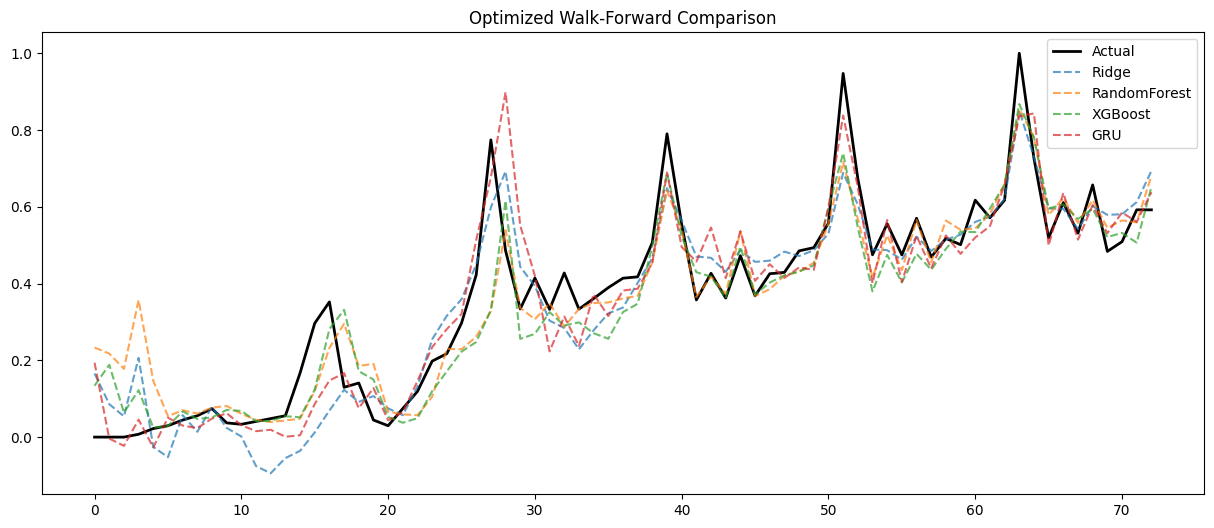

In [10]:
!pip install xgboost tensorflow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
import warnings

warnings.filterwarnings('ignore')

# --- 0. SAFETY CHECK ---
try:
    X_train, X_test, y_train, y_test
    print("Data variables found.")
except NameError:
    print("Variables not found. Preparing data...")
    def prepare_data_local(df_in, window_size=12):
        features = [c for c in ['Arrivals', 'Nights', 'is_covid', 'InterTourismeReceipts', 'REER', 'Oil_price', 'FDI', 'Poverty_rate'] if c in df_in.columns]
        data = df_in[features].interpolate().bfill().ffill().values
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(data)
        X, y = [], []
        for i in range(len(scaled) - window_size):
            X.append(scaled[i:i+window_size, :])
            y.append(scaled[i+window_size, 0])
        X, y = np.array(X), np.array(y)
        split = int(len(X) * 0.8)
        return X[:split], X[split:], y[:split], y[split:]
    X_train, X_test, y_train, y_test = prepare_data_local(df)

X_full = np.concatenate([X_train, X_test], axis=0)
y_full = np.concatenate([y_train, y_test], axis=0)

def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

# --- 3. OPTIMIZED MODEL CONFIGURATION ---
# Define the GRU architecture once to avoid repeated retracing
def get_gru_net(shape):
    m = Sequential([Input(shape=shape), GRU(121), Dropout(0.2), Dense(1)])
    m.compile(optimizer='adam', loss='mse')
    return m

# --- 2. WALK-FORWARD VALIDATION (OPTIMIZED) ---
def walk_forward_validation(X, y, initial_train_size, models_dict):
    results = {}
    n_samples = len(X)
    for name, model_info in models_dict.items():
        print(f"Evaluating {name}...")
        predictions, actuals = [], []

        # For Keras, we build the model structure ONCE outside the time-loop
        shared_model = None
        if model_info['type'] == 'keras':
            shared_model = model_info['model_func'](X.shape[1:])

        for i in range(initial_train_size, n_samples):
            X_tr, y_tr = X[:i], y[:i]
            X_val, y_val = X[i:i+1], y[i:i+1]

            if model_info['type'] == 'sklearn':
                X_tr_f = X_tr.reshape(X_tr.shape[0], -1)
                X_val_f = X_val.reshape(X_val.shape[0], -1)
                model_info['model'].fit(X_tr_f, y_tr)
                pred = model_info['model'].predict(X_val_f)
            else:
                # Train the existing model instance (avoids retracing warning)
                shared_model.fit(X_tr, y_tr, epochs=5, batch_size=16, verbose=0)
                pred = shared_model.predict(X_val, verbose=0)

            predictions.append(pred.flatten()[0])
            actuals.append(y_val[0])

        act, pre = np.array(actuals), np.array(predictions)
        results[name] = {'preds': pre, 'actuals': act, 'MAE': mean_absolute_error(act, pre), 'RMSE': np.sqrt(mean_squared_error(act, pre)), 'MAPE': calculate_mape(act, pre), 'R2': r2_score(act, pre)}
    return results

model_configs = {
    'Ridge': {'type': 'sklearn', 'model': Ridge()},
    'RandomForest': {'type': 'sklearn', 'model': RandomForestRegressor(n_estimators=100)},
    'XGBoost': {'type': 'sklearn', 'model': XGBRegressor(n_estimators=100, learning_rate=0.05)},
    'GRU': {'type': 'keras', 'model_func': get_gru_net}
}

# --- 4. EXECUTION ---
results_dict = walk_forward_validation(X_full, y_full, len(X_train), model_configs)
perf_table = pd.DataFrame({n: {k: v for k, v in m.items() if k not in ['preds', 'actuals']} for n, m in results_dict.items()}).T
display(perf_table.sort_values('RMSE'))

plt.figure(figsize=(15, 6))
plt.plot(results_dict['Ridge']['actuals'], label='Actual', color='black', lw=2)
for name, res in results_dict.items():
    plt.plot(res['preds'], label=name, alpha=0.7, linestyle='--')
plt.title('Optimized Walk-Forward Comparison'); plt.legend(); plt.show()

Starting extended Walk-Forward Validation...
Evaluating Ridge...
Evaluating RandomForest...
Evaluating XGBoost...
Evaluating GRU...
Evaluating LSTM...
Evaluating CNN-LSTM...

--- UPDATED PERFORMANCE LEADERBOARD ---


,MAE,RMSE,MAPE,R2
Ridge,0.070910,0.097461,4.186339e+08,0.837922
XGBoost,0.069942,0.097601,5.293091e+08,0.837458
LSTM,0.072643,0.101840,6.099408e+08,0.823030
RandomForest,0.068610,0.103296,8.791642e+08,0.817935
CNN-LSTM,0.079412,0.107922,7.853213e+08,0.801262
GRU,0.074708,0.119455,2.878663e+08,0.756516


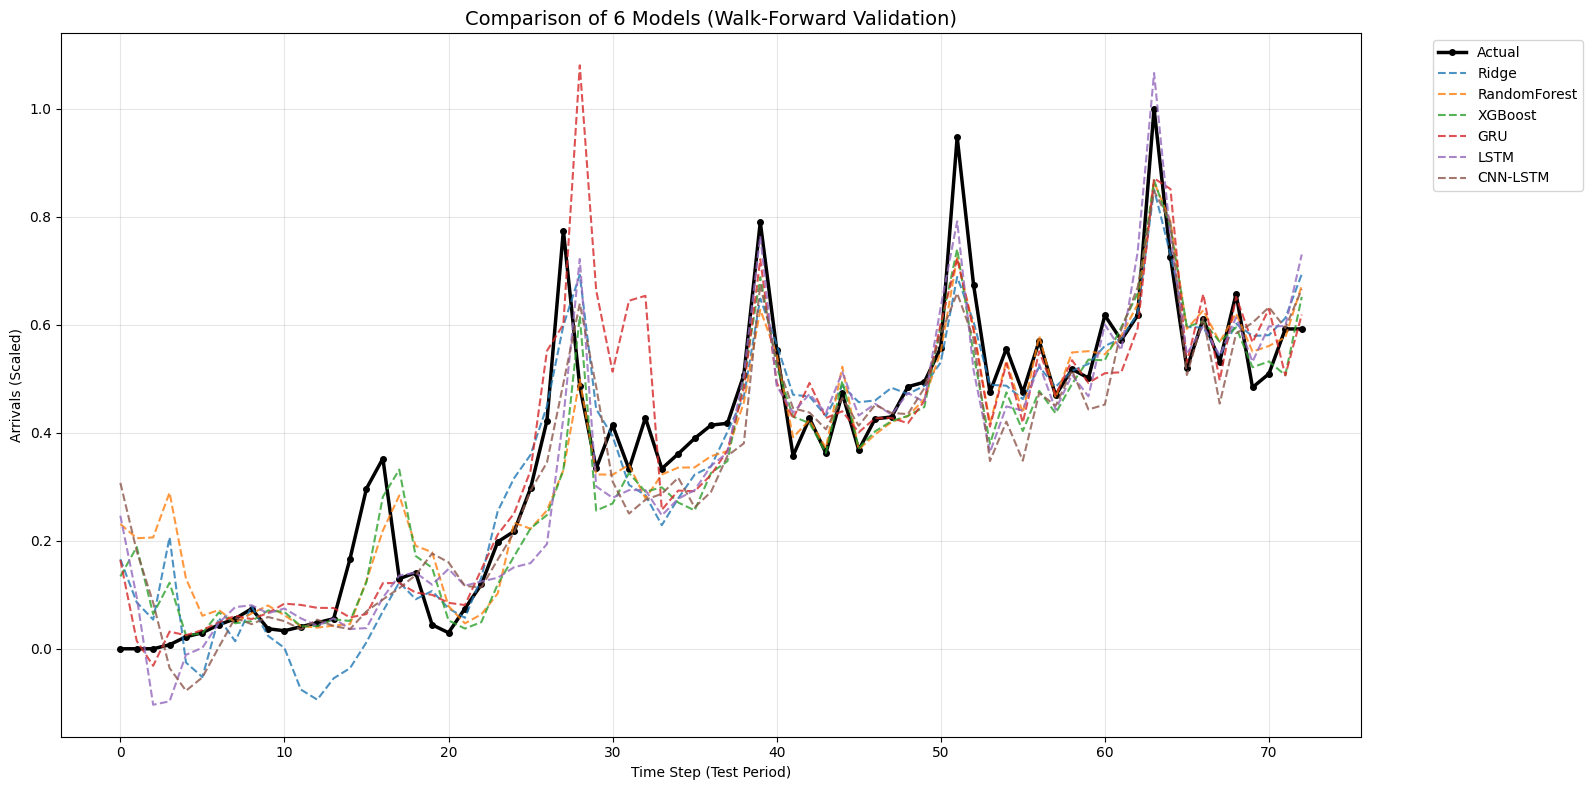

In [11]:
from tensorflow.keras.layers import LSTM, Conv1D, MaxPooling1D, Flatten

# 1. Define additional Deep Learning architectures
def get_lstm_net(shape):
    m = Sequential([
        Input(shape=shape),
        LSTM(121, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

def get_cnn_lstm_net(shape):
    m = Sequential([
        Input(shape=shape),
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        LSTM(64, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

# 2. Update model configurations with the new models
updated_model_configs = {
    'Ridge': {'type': 'sklearn', 'model': Ridge()},
    'RandomForest': {'type': 'sklearn', 'model': RandomForestRegressor(n_estimators=100)},
    'XGBoost': {'type': 'sklearn', 'model': XGBRegressor(n_estimators=100, learning_rate=0.05)},
    'GRU': {'type': 'keras', 'model_func': get_gru_net},
    'LSTM': {'type': 'keras', 'model_func': get_lstm_net},
    'CNN-LSTM': {'type': 'keras', 'model_func': get_cnn_lstm_net}
}

# 3. Run the Walk-Forward Validation with all models
print("Starting extended Walk-Forward Validation...")
full_results = walk_forward_validation(X_full, y_full, len(X_train), updated_model_configs)

# 4. Display Updated Leaderboard
perf_df_extended = pd.DataFrame({n: {k: v for k, v in m.items() if k not in ['preds', 'actuals']}
                               for n, m in full_results.items()}).T
print("\n--- UPDATED PERFORMANCE LEADERBOARD ---")
display(perf_df_extended.sort_values('RMSE'))

# 5. Plot Comparison for all models
plt.figure(figsize=(16, 8))
plt.plot(full_results['Ridge']['actuals'], label='Actual', color='black', lw=2.5, marker='o', markersize=4)
colors = plt.cm.get_cmap('tab10', len(full_results))

for i, (name, res) in enumerate(full_results.items()):
    plt.plot(res['preds'], label=name, alpha=0.8, linestyle='--')

plt.title('Comparison of 6 Models (Walk-Forward Validation)', fontsize=14)
plt.xlabel('Time Step (Test Period)')
plt.ylabel('Arrivals (Scaled)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
!pip install scikeras scikit-learn==1.5.2 optuna tensorflow -q

In [ ]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Input
from tensorflow.keras.optimizers import Adam

# 1. Préparation des données
def prepare_data(df_in, window_size=12):
    df_p = df_in.copy()
    features = [c for c in ['Arrivals', 'Nights', 'is_covid', 'InterTourismeReceipts', 'REER', 'Oil_price', 'FDI', 'Poverty_rate'] if c in df_p.columns and not df_p[c].isnull().all()]
    df_p[features] = df_p[features].interpolate().bfill().ffill()
    data = df_p[features].values
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)

    X, y = [], []
    for i in range(len(scaled_data) - window_size):
        X.append(scaled_data[i:i+window_size, :])
        y.append(scaled_data[i+window_size, 0])

    X, y = np.array(X), np.array(y)
    train_size = int(len(X) * 0.8)
    return X[:train_size], X[train_size:], y[:train_size], y[train_size:], scaler

X_train, X_test, y_train, y_test, scaler = prepare_data(df)

# 2. Fonction Objective pour comparer les architectures
def objective(trial):
    # Choix de l'architecture
    model_type = trial.suggest_categorical('model_type', ['RNN', 'GRU', 'LSTM', 'CNN-LSTM', 'Stacked_LSTM'])
    units = trial.suggest_int('units', 32, 128)
    dropout = trial.suggest_float('dropout', 0.1, 0.4)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = Sequential()

    if model_type == 'RNN':
        model.add(SimpleRNN(units, input_shape=(X_train.shape[1], X_train.shape[2])))
    elif model_type == 'GRU':
        model.add(GRU(units, input_shape=(X_train.shape[1], X_train.shape[2])))
    elif model_type == 'LSTM':
        model.add(LSTM(units, input_shape=(X_train.shape[1], X_train.shape[2])))
    elif model_type == 'Stacked_LSTM':
        model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(dropout))
        model.add(LSTM(units // 2))
    elif model_type == 'CNN-LSTM':
        model.add(Conv1D(filters=32, kernel_size=3, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(MaxPooling1D(pool_size=2))
        model.add(LSTM(units))

    model.add(Dropout(dropout))
    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=0)

    preds = model.predict(X_test, verbose=0)
    return mean_squared_error(y_test, preds)

# 3. Exécution de l'optimisation
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)

print(f"\nMeilleure architecture: {study.best_params['model_type']}")
print(f"Meilleurs hyperparamètres: {study.best_params}")

# 4. Évaluation finale
best_p = study.best_params
final_model = Sequential()
if best_p['model_type'] == 'RNN':
    final_model.add(SimpleRNN(best_p['units'], input_shape=(X_train.shape[1], X_train.shape[2])))
elif best_p['model_type'] == 'GRU':
    final_model.add(GRU(best_p['units'], input_shape=(X_train.shape[1], X_train.shape[2])))
elif best_p['model_type'] == 'LSTM':
    final_model.add(LSTM(best_p['units'], input_shape=(X_train.shape[1], X_train.shape[2])))
elif best_p['model_type'] == 'Stacked_LSTM':
    final_model.add(LSTM(best_p['units'], return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    final_model.add(Dropout(best_p['dropout']))
    final_model.add(LSTM(best_p['units'] // 2))
elif best_p['model_type'] == 'CNN-LSTM':
    final_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    final_model.add(MaxPooling1D(pool_size=2))
    final_model.add(LSTM(best_p['units']))

final_model.add(Dropout(best_p['dropout']))
final_model.add(Dense(1))
final_model.compile(optimizer=Adam(learning_rate=best_p['lr']), loss='mse')
final_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

y_pred = final_model.predict(X_test)
print(f"\nRésultats Finaux ({best_p['model_type']}):")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

[I 2026-05-20 10:48:16,529] A new study created in memory with name: no-name-17b54f97-8ca6-42e9-80ec-89eaaa4ca1a2
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2026-05-20 10:48:18,802] Trial 0 finished with value: 0.0551900501740806 and parameters: {'model_type': 'RNN', 'units': 78, 'dropout': 0.20745046700719452, 'lr': 0.00011426775349130977}. Best is trial 0 with value: 0.0551900501740806.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2026-05-20 10:48:22,275] Trial 1 finished with value: 0.02184349996955776


Meilleure architecture: GRU
Meilleurs hyperparamètres: {'model_type': 'GRU', 'units': 121, 'dropout': 0.2971957133949092, 'lr': 0.004968935569238167}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

Résultats Finaux (GRU):
R2 Score: 0.5379
RMSE: 0.1646
